In [ ]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import os
import seaborn as sns
import re

FONTSIZE = 14
TICKSIZE = 12  
FOLDER = "output-figures"
os.makedirs(FOLDER, exist_ok=True)

# put jax in cpu mode
jax.config.update("jax_platform_name", "cpu")

results_folder = "RESULTS-MNIST-OOD"

# Function to find paths with correct optimizer
def find_paths(results_folder, optimizer):
    paths = []
    for root, dirs, files in os.walk(results_folder):
        for dir_name in dirs:
            if re.search(f"opt={optimizer}", dir_name):
                paths.append(os.path.join(root, dir_name))
    return paths

optimizers = ["mesu", "bgd", "sgd", "sgd-stream-ewc=5"]
paths = [path for optimizer in optimizers for path in find_paths(results_folder, optimizer)]

colormap = plt.cm.get_cmap("viridis", 5)
names = ["MESU", "BGD", "SGD", "EWC Stream"]

n_iterations = 5
n_tasks = 1
n_epochs = 1000

data = []
for path in paths:
    full_accuracies, full_epistemic_roc_auc, full_aleatoric_roc_auc, full_epistemic, full_ood_epistemic, full_aleatoric, full_ood_aleatoric, full_params_0, full_params_1 = [], [], [], [], [], [], [], [], []
    for it in range(n_iterations):
        current_it_path = os.path.join(path, f"config{it}")
        accuracy_path = os.path.join(current_it_path, "accuracy")
        uncertainty_path = os.path.join(current_it_path, "uncertainty")
        weights_path = os.path.join(current_it_path, "weights")
        
        accuracies, epistemic_roc_auc, aleatoric_roc_auc, epistemic, ood_epistemic, aleatoric, ood_aleatoric = [], [], [], [], [], [], []
        
        for task in range(n_tasks):
            for epoch in range(n_epochs):
                suffix = f"task={task}-epoch={epoch}.npy"
                accuracies.append(jnp.load(os.path.join(accuracy_path, suffix)))
                epistemic_roc_auc.append(jnp.load(os.path.join(uncertainty_path, f"roc-auc-epistemic-{suffix}")))
                aleatoric_roc_auc.append(jnp.load(os.path.join(uncertainty_path, f"roc-auc-aleatoric-{suffix}")))
                epistemic.append(jnp.load(os.path.join(uncertainty_path, f"epistemic-{suffix}")))
                ood_epistemic.append(jnp.load(os.path.join(uncertainty_path, f"ood-epistemic-{suffix}")))
                aleatoric.append(jnp.load(os.path.join(uncertainty_path, f"aleatoric-{suffix}")))
                ood_aleatoric.append(jnp.load(os.path.join(uncertainty_path, f"ood-aleatoric-{suffix}")))
        
        if "bgd" in path or "mesu" in path:
            param_sigma_0, param_sigma_1 = [], []
            for task in range(n_tasks):
                for epoch in range(n_epochs):
                    suffix = f"task={task}-epoch={epoch}.npy"
                    param_sigma_0.append(jnp.load(os.path.join(weights_path, f"layer=1-{suffix}")))
                    param_sigma_1.append(jnp.load(os.path.join(weights_path, f"layer=3-{suffix}")))
        
        
        full_accuracies.append(jnp.array(accuracies))
        full_epistemic_roc_auc.append(jnp.array(epistemic_roc_auc))
        full_aleatoric_roc_auc.append(jnp.array(aleatoric_roc_auc))
        full_epistemic.append(jnp.array(epistemic))
        full_ood_epistemic.append(jnp.array(ood_epistemic))
        full_aleatoric.append(jnp.array(aleatoric))
        full_ood_aleatoric.append(jnp.array(ood_aleatoric))
        if "bgd" in path or "mesu" in path:
            full_params_0.append(jnp.array(param_sigma_0))
            full_params_1.append(jnp.array(param_sigma_1))
    
    data.append((
        jnp.array(full_accuracies), 
        jnp.array(full_epistemic_roc_auc), 
        jnp.array(full_aleatoric_roc_auc), 
        jnp.array(full_epistemic), 
        jnp.array(full_ood_epistemic), 
        jnp.array(full_aleatoric),
        jnp.array(full_ood_aleatoric),
        jnp.array(full_params_0),
        jnp.array(full_params_1)
    ))


/tmp/ipykernel_721488/1944527904.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap("viridis", 5)


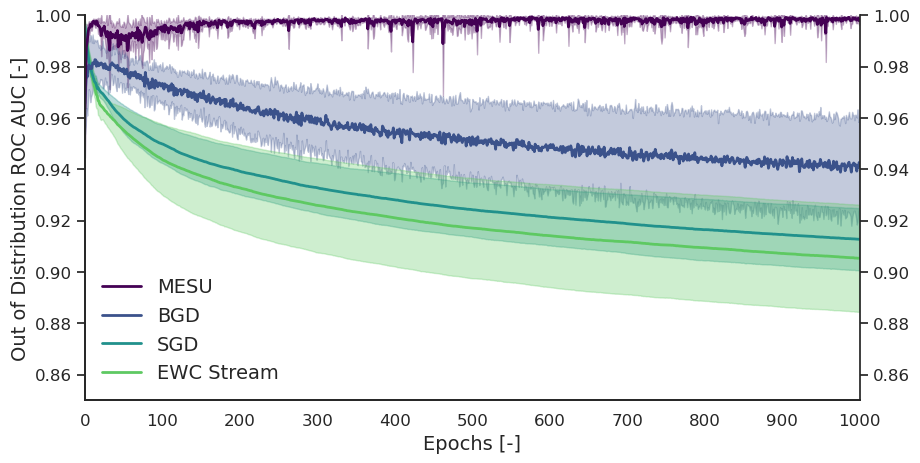

In [ ]:
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 5))
for i, alg, name in zip(range(len(data)), data, names):
    full_roc = alg[1]
    full_roc_mean = jnp.mean(full_roc, axis=0)
    full_roc_std = jnp.std(full_roc, axis=0)
    if jnp.all(full_roc_mean == 0):
        full_roc_mean = alg[2].mean(axis=0)
        full_roc_std = alg[2].std(axis=0)
    sns.lineplot(x=jnp.arange(n_epochs), y=full_roc_mean, ax=ax, label=name, color=colormap(i), linewidth=2, zorder=10 - i)
    ax.fill_between(jnp.arange(n_epochs), full_roc_mean - full_roc_std, full_roc_mean + full_roc_std, color=colormap(i), alpha=0.3)

ax.set_xlabel("Epochs [-]", fontsize=FONTSIZE)
ax.set_ylabel("Out of Distribution ROC AUC [-]", fontsize=FONTSIZE)
ax.set_xticks(jnp.arange(0, n_epochs + 1, 100))
ax.tick_params(axis='both', which='major', labelsize=TICKSIZE)
ax.legend(loc="lower left", fontsize=FONTSIZE, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, n_epochs)
ax.set_ylim(0.85, 1)

ax2 = ax.twinx()
ax2.tick_params(axis='both', which='major', labelsize=TICKSIZE)
ax2.spines['top'].set_visible(False)
ax2.set_ylim(0.85, 1)

plt.show()
# savefig as pdf
fig.savefig(os.path.join(FOLDER, "mnist-roc-auc.svg"), bbox_inches="tight")
fig.savefig(os.path.join(FOLDER, "mnist-roc-auc.pdf"), bbox_inches="tight")
plt.close()

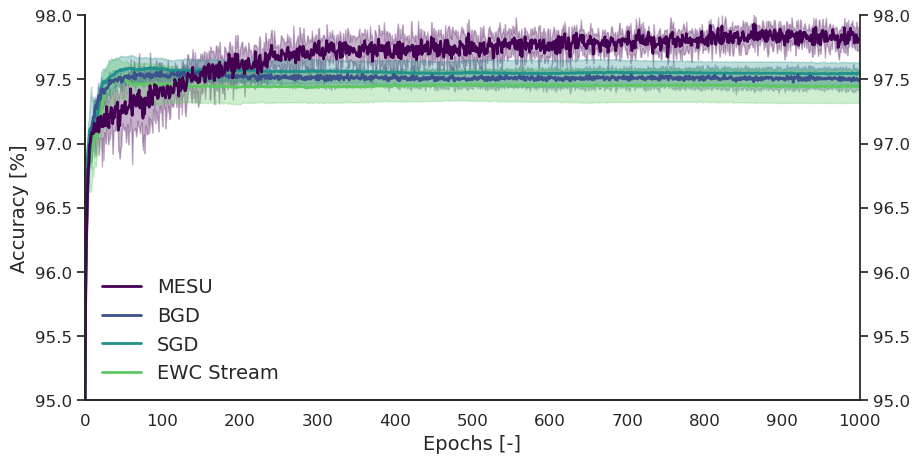

In [ ]:
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 5))
for i, alg, name in zip(range(len(data)), data, names):
    full_acc = alg[0]*100
    full_acc_mean = jnp.mean(full_acc, axis=0)[:, 0, 0]
    full_acc_std = jnp.std(full_acc, axis=0)[:, 0, 0]
    sns.lineplot(x=jnp.arange(n_epochs), y=full_acc_mean, ax=ax, label=name, color=colormap(i), linewidth=2, zorder = 10 - i)
    ax.fill_between(jnp.arange(n_epochs), full_acc_mean - full_acc_std, full_acc_mean + full_acc_std, color=colormap(i), alpha=0.3)
ax.set_xlabel("Epochs [-]", fontsize=FONTSIZE)
ax.set_ylabel("Accuracy [%]", fontsize=FONTSIZE)
ax.set_xticks(jnp.arange(0, n_epochs+1, 100))
ax.tick_params(axis='both', which='major', labelsize=TICKSIZE)
ax.legend(loc="lower left", fontsize=FONTSIZE, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax2 = ax.twinx()
ax2.tick_params(axis='both', which='major', labelsize=TICKSIZE)
ax2.spines['top'].set_visible(False)
ax.set_xlim(0, n_epochs)
ax.set_ylim(95, 98)
ax2.set_ylim(95, 98)
plt.show()
# savefig as pdf
fig.savefig(os.path.join(FOLDER, "mnist-acc.svg"), bbox_inches="tight")
fig.savefig(os.path.join(FOLDER, "mnist-acc.pdf"), bbox_inches="tight")
plt.close()

/tmp/ipykernel_721488/1719791068.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap("viridis", len(data)+1)


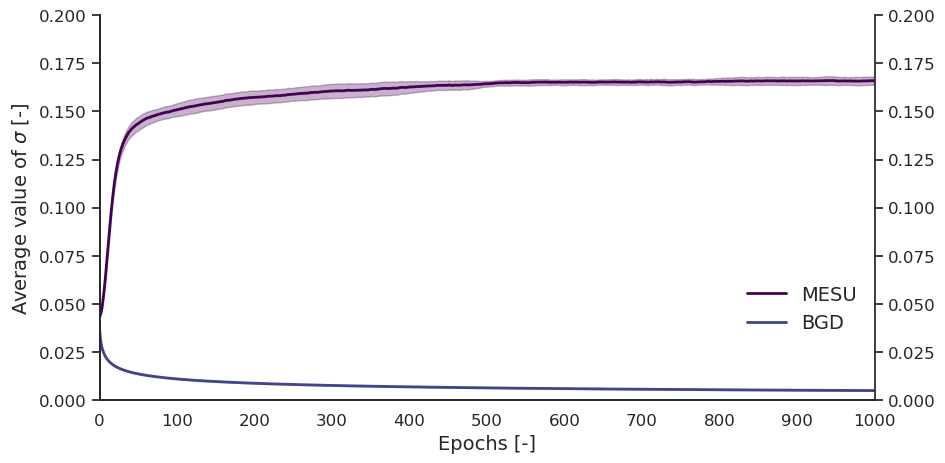

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colormap = plt.cm.get_cmap("viridis", len(data)+1)
for i, alg, name in zip(range(len(data)-2), data, names):
    if "BGD" in name or "MESU" in name:
        full_params_l0 = alg[-2]
        full_params_l1 = alg[-1]
        # Compute mean, std on synapses and samples
        full_params_l0_mean = full_params_l0.reshape(n_iterations, n_epochs, -1).mean(axis=(0, -1))
        full_params_l1_mean = full_params_l1.reshape(n_iterations, n_epochs, -1).mean(axis=(0, -1))
        full_params_l0_std = full_params_l0.reshape(n_iterations, n_epochs, -1).mean(axis=-1).std(axis=0)
        full_params_l1_std = full_params_l1.reshape(n_iterations, n_epochs, -1).mean(axis=-1).std(axis=0)
        # Compute the mean through layers
        full_params_mean = (full_params_l0_mean + full_params_l1_mean)/2
        full_params_std = (full_params_l0_std + full_params_l1_std)/2
        sns.lineplot(x=jnp.arange(n_epochs), y=full_params_mean, ax=ax, label=name, color=colormap(i), linewidth=2, zorder=10 - i)
        ax.fill_between(jnp.arange(n_epochs), full_params_mean - full_params_std, full_params_mean + full_params_std, color=colormap(i), alpha=0.3)           
ax.set_xlabel("Epochs [-]", fontsize=FONTSIZE)
ax.set_ylabel("Average value of $\sigma$ [-]", fontsize=FONTSIZE)
ax.set_xticks(jnp.arange(0, n_epochs+1, 100))
ax.tick_params(axis='both', which='major', labelsize=TICKSIZE)
ax.legend(loc="lower right", fontsize=FONTSIZE, frameon=False, bbox_to_anchor=(1, 0.13))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax2 = ax.twinx()
ax2.tick_params(axis='both', which='major', labelsize=TICKSIZE)
ax2.spines['top'].set_visible(False)
ax.set_xlim(0, n_epochs)
ax.set_ylim(0, 0.2)
ax2.set_ylim(0, 0.2)
plt.show()
# savefig as pdf
fig.savefig(os.path.join(FOLDER, "mnist-vanishing-sigma.svg"), bbox_inches="tight")
fig.savefig(os.path.join(FOLDER, "mnist-vanishing-sigma.pdf"), bbox_inches="tight")
plt.close()

MESU ROC AUC: 0.9998922348022461


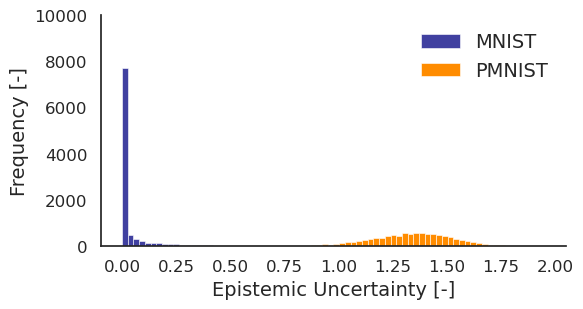

BGD ROC AUC: 0.9984059929847717


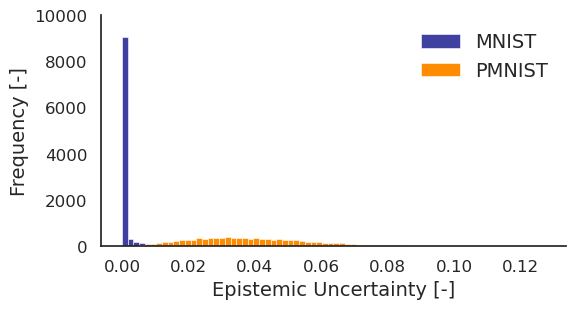

In [35]:
bins = 75
for i, alg, name in zip(range(len(data)), data, names):
    if "BGD" in name or "MESU" in name:
        fig, ax = plt.subplots(figsize=(6, 3))
        full_mnist_epistemic = alg[3].mean(axis=0)[-1]
        full_pmnist_epistemic = alg[4].mean(axis=0)[-1]
        min_val = min(full_mnist_epistemic.min(), full_pmnist_epistemic.min())
        max_val = max(full_mnist_epistemic.max(), full_pmnist_epistemic.max())
        thresholds = jnp.linspace(min_val, max_val, 1000)
        tpr = jnp.array([jnp.mean(full_mnist_epistemic < t) for t in thresholds])
        fpr = jnp.array([jnp.mean(full_pmnist_epistemic < t) for t in thresholds])
        roc_auc = jnp.trapezoid(tpr, fpr)
        print(f"{name} ROC AUC: {roc_auc}")
        
        x_bins = jnp.linspace(min_val, max_val, bins)
        sns.histplot(full_mnist_epistemic, bins=x_bins, alpha=0.75, label="MNIST", ax=ax, color="navy")
        sns.histplot(full_pmnist_epistemic, bins=x_bins, alpha=1, label="PMNIST", ax=ax, color="darkorange")
        ax.set_xlabel("Epistemic Uncertainty [-]", fontsize=FONTSIZE)
        ax.set_ylabel("Frequency [-]", fontsize=FONTSIZE)
        ax.tick_params(axis='both', which='major', labelsize=TICKSIZE)
        ax.set_ylim(0, 10000)
        ax.legend(loc="upper right", fontsize=FONTSIZE, frameon=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.show()


MESU ROC AUC: 0.9522167444229126


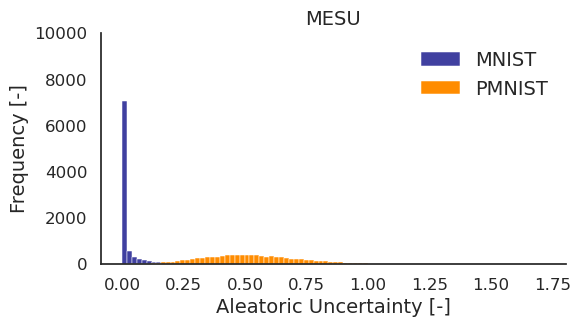

BGD ROC AUC: 0.9431804418563843


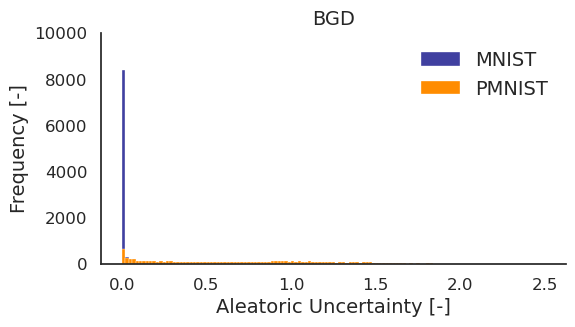

SGD ROC AUC: 0.9152026176452637


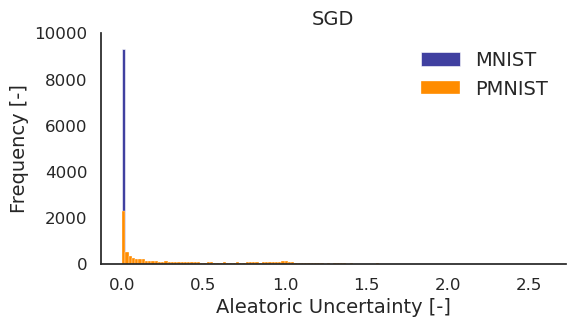

EWC Stream ROC AUC: 0.9115076065063477


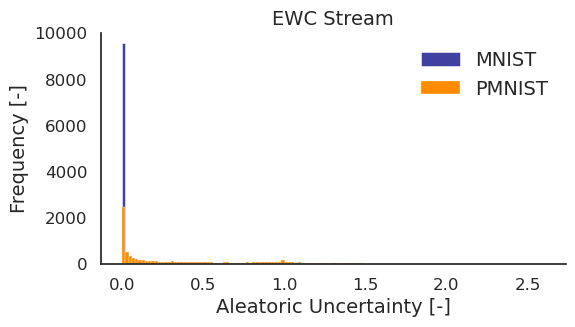

In [ ]:
bins = 100
for i, alg, name in zip(range(len(data)), data, names):
    fig, ax = plt.subplots(figsize=(6, 3))
    full_mnist_epistemic = alg[5][0][-1]
    full_pmnist_epistemic = alg[6][0][-1]
    # compute roc auc    
    min_val = min(full_mnist_epistemic.min(), full_pmnist_epistemic.min())
    max_val = max(full_mnist_epistemic.max(), full_pmnist_epistemic.max())
    thresholds = jnp.linspace(min_val, max_val, 1000)
    tpr = jnp.array([jnp.mean(full_mnist_epistemic < t) for t in thresholds])
    fpr = jnp.array([jnp.mean(full_pmnist_epistemic < t) for t in thresholds])
    roc_auc = jnp.trapezoid(tpr, fpr)
    print(f"{name} ROC AUC: {roc_auc}")
    
    x_bins = jnp.linspace(min_val, max_val, bins)
    sns.histplot(full_mnist_epistemic, bins=x_bins, alpha=0.75, label="MNIST", ax=ax, color="navy", binwidth=0.02)
    sns.histplot(full_pmnist_epistemic, bins=x_bins, alpha=1, label="PMNIST", ax=ax, color="darkorange", binwidth=0.02)
    ax.set_xlabel("Aleatoric Uncertainty [-]", fontsize=FONTSIZE)
    ax.set_ylabel("Frequency [-]", fontsize=FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICKSIZE)
    ax.set_ylim(0, 10000)
    ax.legend(loc="upper right", fontsize=FONTSIZE, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(name, fontsize=FONTSIZE)
    plt.show()